## DS 5030 Understanding Uncertainty Lab 1 - uva_analysis.ipynb ##
**By Fiona St. Clair**

loading and cleaning data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
df = pd.read_csv("ForeignGifts_edu.csv")

country_col = "Country of Giftor"
institution_col = "Institution Name"
amount_col = "Foreign Gift Amount"
gifttype_col = "Gift Type"

df[amount_col] = pd.to_numeric(df[amount_col], errors='coerce')
df = df.dropna(subset=[amount_col])

print("shape:", df.shape)

shape: (28221, 10)


making UVA and list of other schools

In [3]:
UVA_NAME = "University of Virginia"
PEER_SCHOOLS = [
    "University of Michigan - Ann Arbor",
    "University of North Carolina - Chapel Hill",
    "University of California, Berkeley",
    "University of California, Los Angeles",
    "University of Texas at Austin",
    "Georgia Institute of Technology",
    "Ohio State University (The)",
    "Pennsylvania State University (The)",]

In [4]:
all_institutions = df[institution_col].unique()
print()
print("UVA in data?", UVA_NAME in all_institutions)
for school in PEER_SCHOOLS:
    print(school, "in data?", school in all_institutions)


UVA in data? True
University of Michigan - Ann Arbor in data? True
University of North Carolina - Chapel Hill in data? True
University of California, Berkeley in data? True
University of California, Los Angeles in data? True
University of Texas at Austin in data? True
Georgia Institute of Technology in data? True
Ohio State University (The) in data? True
Pennsylvania State University (The) in data? True


uva analysis

In [5]:
uva = df[df[institution_col] == UVA_NAME]

print()
print("UVA total number of gifts:", len(uva))
print("UVA total $ received:", uva[amount_col].sum())
print("UVA average gift:", uva[amount_col].mean())
print("UVA median gift:", uva[amount_col].median())

print()
print("UVA gifts broken down by country:")
uva_by_country = uva.groupby(country_col)[amount_col].agg(['sum', 'count']).sort_values('sum', ascending=False)
print(uva_by_country)

print()
print("UVA gifts broken down by gift type:")
print(uva.groupby(gifttype_col)[amount_col].agg(['sum', 'count']))



UVA total number of gifts: 98
UVA total $ received: 22189238
UVA average gift: 226420.79591836734
UVA median gift: 80535.5

UVA gifts broken down by country:
                       sum  count
Country of Giftor                
BANGLADESH         4228589     10
SWEDEN             4007552     10
TANZANIA           2776447      3
SWITZERLAND        2000000      2
ENGLAND            1950666     31
GUERNSEY           1500000      3
FINLAND            1008384      7
BERMUDA             900000      1
KOREA               862787      6
SINGAPORE           805000      2
THE NETHERLANDS     725670      4
ISRAEL              623655     12
RWANDA              284135      1
JAPAN               265970      1
FRANCE              250383      5

UVA gifts broken down by gift type:
                    sum  count
Gift Type                     
Contract       14807636     64
Monetary Gift   7381602     34


uva vs other schools

In [6]:
schools_to_compare = PEER_SCHOOLS + [UVA_NAME]
peers = df[df[institution_col].isin(PEER_SCHOOLS)]

school_totals = (
    df[df[institution_col].isin(schools_to_compare)]
    .groupby(institution_col)[amount_col]
    .agg(['sum', 'count', 'mean'])
    .sort_values('sum', ascending=False)
)

print()
print("UVA vs each peer school (sorted by total $):")
print(school_totals)

rank = school_totals['sum'].rank(ascending=False)
print()
print("UVA's rank among peer group:", rank[UVA_NAME])


UVA vs each peer school (sorted by total $):
                                                  sum  count      mean
Institution Name                                                      
University of California, Berkeley          294479904    394 747410.92
University of Michigan - Ann Arbor          287336783    715 401869.63
University of California, Los Angeles       242146363   3916  61835.13
University of Texas at Austin                85858408    377 227741.14
Georgia Institute of Technology              77979361    203 384134.78
Ohio State University (The)                  58277670   1014  57473.05
Pennsylvania State University (The)          43458897    174 249763.78
University of North Carolina - Chapel Hill   41292544    286 144379.52
University of Virginia                       22189238     98 226420.80

UVA's rank among peer group: 9.0


uva vs entire market

In [7]:
market_total = df[amount_col].sum()
uva_total = uva[amount_col].sum()
uva_share_of_market = uva_total / market_total * 100

print()
print("total $ across every school in the dataset ('market'):", market_total)
print("UVA's total:", uva_total)
print("UVA's share of the whole market: {:.3f}%".format(uva_share_of_market))

peer_avg_total = school_totals.loc[PEER_SCHOOLS, 'sum'].mean()
print("average total $ raised per peer school:", peer_avg_total)
print("UVA total minus peer average (negative = UVA behind peers):", uva_total - peer_avg_total)


total $ across every school in the dataset ('market'): 16600515514
UVA's total: 22189238
UVA's share of the whole market: 0.134%
average total $ raised per peer school: 141353741.25
UVA total minus peer average (negative = UVA behind peers): -119164503.25


countries that uva recieves little money from but donate lots to others (potential donors)

In [8]:
peer_by_country = peers.groupby(country_col)[amount_col].sum()
uva_by_country_series = uva.groupby(country_col)[amount_col].sum()

gap = pd.DataFrame({
    'peer_total': peer_by_country,
    'uva_total': uva_by_country_series
}).fillna(0)

# dividing by number of peer schools so it's a fair "per school"
# comparison instead of just comparing 1 school (UVA) to 10 schools combined
gap['peer_avg_per_school'] = gap['peer_total'] / len(PEER_SCHOOLS)
gap['gap_vs_uva'] = gap['peer_avg_per_school'] - gap['uva_total']

gap_sorted = gap.sort_values('gap_vs_uva', ascending=False)

print()
print("top 15 countries where peer schools out-raise UVA the most (biggest opportunities):")
print(gap_sorted.head(15))



top 15 countries where peer schools out-raise UVA the most (biggest opportunities):
                    peer_total  uva_total  peer_avg_per_school  gap_vs_uva
Country of Giftor                                                         
ENGLAND           161440574.00 1950666.00          20180071.75 18229405.75
JAPAN             119635107.00  265970.00          14954388.38 14688418.38
CHINA             111563208.00       0.00          13945401.00 13945401.00
SAUDI ARABIA       71356070.00       0.00           8919508.75  8919508.75
GERMANY            70056487.00       0.00           8757060.88  8757060.88
CANADA             59065282.00       0.00           7383160.25  7383160.25
SWITZERLAND        68631645.00 2000000.00           8578955.62  6578955.62
HONG KONG          52379238.00       0.00           6547404.75  6547404.75
FRANCE             47795994.00  250383.00           5974499.25  5724116.25
KOREA              51678312.00  862787.00           6459789.00  5597002.00
THE NETHERLANDS

charting

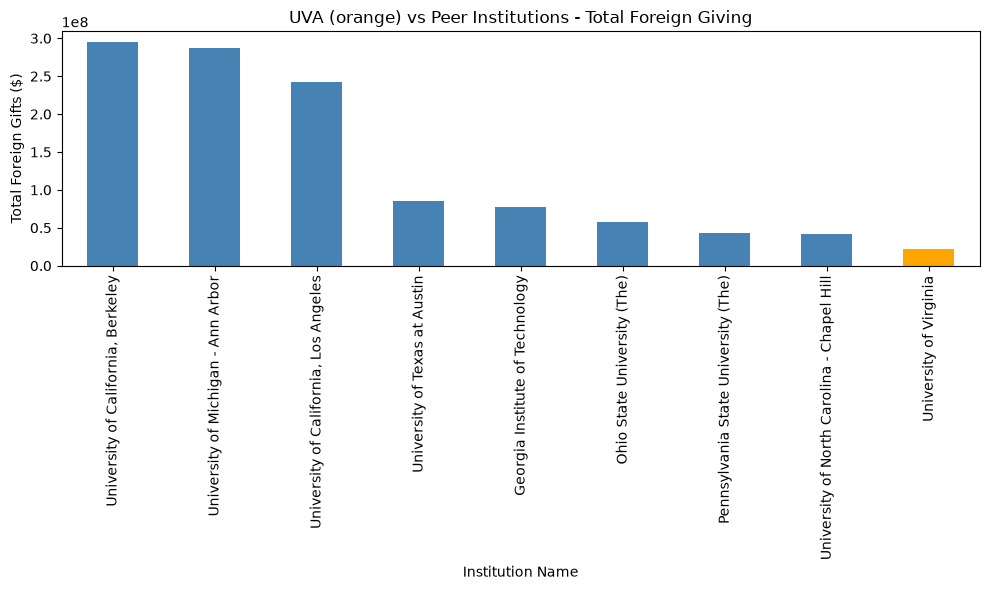

In [9]:
plot_data = school_totals['sum'].sort_values(ascending=False)
bar_colors = ['orange' if school == UVA_NAME else 'steelblue' for school in plot_data.index]

plt.figure(figsize=(10, 6))
plot_data.plot(kind='bar', color=bar_colors)
plt.ylabel("Total Foreign Gifts ($)")
plt.title("UVA (orange) vs Peer Institutions - Total Foreign Giving")
plt.tight_layout()
plt.savefig("uva_vs_peers.png")
plt.show()

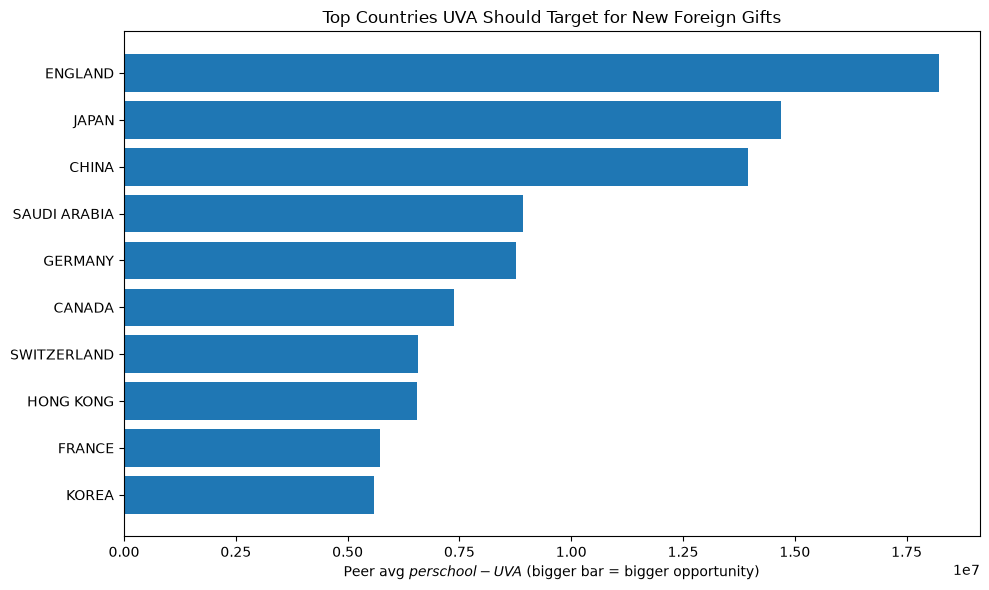

In [10]:
top_gap = gap_sorted.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_gap.index, top_gap['gap_vs_uva'])
plt.xlabel("Peer avg $ per school - UVA $ (bigger bar = bigger opportunity)")
plt.title("Top Countries UVA Should Target for New Foreign Gifts")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("uva_opportunity_countries.png")
plt.show()